In [34]:
from models.PP3DR import PP3DR
from models.mixed_head import PP3DR_mixed_head
import torch
from datasets.nrgbd_dataset import nrgbd_dataset
from datasets.dtu_dataset import dtu_dataset
from datasets.dynamic_replica.dynamic_replica_dataset import dynamic_replica_dataset
from datasets.eth3d_dataset import eth3d_dataset
from datasets.flying_things_3d.flying_things_3d_dataset import flying_things_3d_dataset
from datasets.rtmv.rtmv_dataset import rtmv_dataset
from datasets.sintel.sintel_dataset import sintel_dataset
import matplotlib.pyplot as plt

In [35]:
model = PP3DR()
remove_front = False
# I want to see which parameters are left over after loading this.
loaded_state_dict = torch.load("/vulcanscratch/hughma/PP3DR/new_design_datasets-l1-normal/PP3DR.pth", weights_only=True)
if remove_front:
    # The lines here are necessary if all the loaded state dict entries begin with an extra "module."
    new_state_dict = {}
    for key in loaded_state_dict:
        new_state_dict[key[7:]] = loaded_state_dict[key]
    model.load_state_dict(new_state_dict)
else:
    model.load_state_dict(loaded_state_dict)
print("post load")

model = model.eval().to("cuda")

post load


In [53]:
# dataset = nrgbd_dataset()
# dataset = flying_things_3d_dataset()
# dataset = sintel_dataset()
dataset = rtmv_dataset()

Loaded RTMV dataset from /vulcanscratch/hughma/PP3DR/datasets/rtmv/rtmv_dataset_cache.pth.


post dataset
post pred
log_depths: (1, 10, 512, 512)
focal_length: (1,)
relative_camera_translations: (1, 9, 3)
relative_camera_rotations: (1, 9, 3, 3)
done
2.2816076


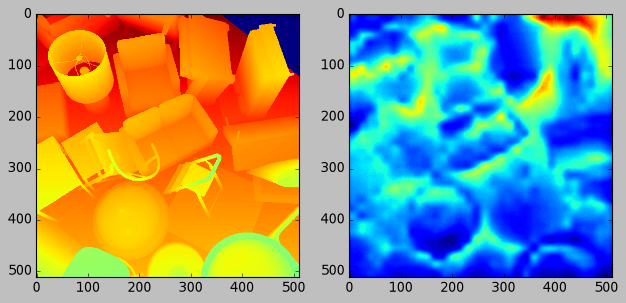

In [54]:
data = dataset[60] # 8
print("post dataset")
for key in data:
    data[key] = data[key].unsqueeze(0)
with torch.amp.autocast("cuda", dtype = torch.bfloat16), torch.no_grad():
    pred = model(data['images'].to("cuda"), data['rope_x'].to("cuda"), data['rope_y'].to("cuda"))
print("post pred")
for key in pred:
    pred[key] = pred[key].to(torch.float32).cpu().numpy(force=True)
    print(f"{key}: {pred[key].shape}")
print("done")
import numpy as np
# plt.style.use("seaborn-v0_8-darkgrid")
plt.style.use("classic")
fig, (a1, a2) = plt.subplots(1, 2)
data['depths'][data['depths'] < 0] = 0
a1.imshow(data['depths'][0][0])
a2.imshow(np.exp(pred['log_depths'][0][0]))
print(pred['log_depths'][0][0].mean())
fig.tight_layout()